<a href="https://colab.research.google.com/github/mamunh9/Autonomous-Systems-Lab/blob/main/Lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 06 — Robust Machine Learning Systems for Sensor/Fault Detection

This lab extends Lab 05 from SVM classification toward engineering-grade ML evaluation.

You will work with a realistic synthetic sensor/fault-detection dataset. The task is binary classification:

- `0 = normal operation`
- `1 = fault condition`

Main topics: preprocessing, validation, robustness testing, ROC/AUC, grid search, and why accuracy alone is not enough.

## Learning objectives

After this lab, you should be able to:

1. explain accuracy, precision, recall, F1-score, ROC curve, and AUC,
2. interpret a confusion matrix,
3. use preprocessing pipelines,
4. use cross-validation and grid search,
5. test simple robustness against sensor noise,
6. discuss metric choices for safety-relevant fault detection.

## 1. Imports

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    RocCurveDisplay, roc_auc_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Sensor/fault dataset

In [9]:
def generate_sensor_fault_data(n_normal=450, n_fault=50, random_state=42):
    rng = np.random.default_rng(random_state)
    normal = pd.DataFrame({
        "temperature_C": rng.normal(65, 5, n_normal),
        "vibration_mm_s": rng.normal(2.0, 0.4, n_normal),
        "pressure_bar": rng.normal(5.0, 0.5, n_normal),
        "motor_current_A": rng.normal(10.0, 1.0, n_normal),
        "rotational_speed_rpm": rng.normal(1500, 80, n_normal),
        "load_percent": rng.normal(60, 10, n_normal),
    })
    normal["fault"] = 0
    fault = pd.DataFrame({
        "temperature_C": rng.normal(82, 8, n_fault),
        "vibration_mm_s": rng.normal(4.0, 0.9, n_fault),
        "pressure_bar": rng.normal(4.3, 0.7, n_fault),
        "motor_current_A": rng.normal(13.5, 1.8, n_fault),
        "rotational_speed_rpm": rng.normal(1420, 120, n_fault),
        "load_percent": rng.normal(75, 12, n_fault),
    })
    fault["fault"] = 1
    df = pd.concat([normal, fault], ignore_index=True)
    return df.sample(frac=1, random_state=random_state).reset_index(drop=True)

df = generate_sensor_fault_data()
df.head()

,temperature_C,vibration_mm_s,pressure_bar,motor_current_A,rotational_speed_rpm,load_percent,fault
0,66.916969,1.768842,5.048707,7.724264,1424.483718,68.237209,0
1,67.485804,1.923462,5.308407,11.401186,1404.450762,60.117164,0
2,67.770583,1.255262,4.688200,11.127355,1526.803389,54.479753,0
3,73.839650,2.216453,5.736007,10.498719,1418.037687,43.525037,0
4,60.331912,1.965162,5.001497,11.467181,1549.528401,48.148154,0


### Exercise 1 — Inspect the data

1. Show summary statistics with `df.describe()`.
2. Show class counts for `fault`.
3. Explain why this is an imbalanced dataset.
4. Explain why imbalance is common in fault detection.

3. This dataset is imbalanced because One class normal has much more data than the other class fault.
4. Imbalance is natural in real-world systems because machines operate normally most of the time and faults are rare events.

In [10]:
df.describe()

,temperature_C,vibration_mm_s,pressure_bar,motor_current_A,rotational_speed_rpm,load_percent,fault
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,66.602184,2.186111,4.939174,10.255408,1487.346471,62.024280,0.1000
std,7.285201,0.791929,0.562648,1.534623,85.760232,11.839418,0.3003
min,52.166708,0.814188,2.959104,7.044381,1091.256025,29.362201,0.0000
25%,62.040675,1.736523,4.619562,9.342046,1435.440571,54.575667,0.0000
50%,65.769980,2.030600,4.981463,10.060686,1497.374726,61.761943,0.0000
75%,69.203431,2.357782,5.307071,10.900360,1543.976148,69.733025,0.0000
max,101.665949,6.371267,6.404605,19.007156,1728.595074,103.682673,1.0000


In [11]:
print(df["fault"].value_counts().sort_index())
print(df["fault"].value_counts(normalize=True).sort_index())

fault
0    450
1     50
Name: count, dtype: int64
fault
0    0.9
1    0.1
Name: proportion, dtype: float64


## 3. Train/test split

In [12]:
X = df.drop(columns=["fault"])
y = df["fault"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train class distribution:")
print(y_train.value_counts(normalize=True).sort_index())
print("Test class distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Train: (350, 6) Test: (150, 6)
Train class distribution:
fault
0    0.9
1    0.1
Name: proportion, dtype: float64
Test class distribution:
fault
0    0.9
1    0.1
Name: proportion, dtype: float64


### Exercise 2
Explain `test_size=0.30`, `random_state=42`, and `stratify=y`.

1. test_size=0.30: This means 30% of the data is used for testing and 70% of the data is used for training.
2. random_state=42: This sets a fixed random seed that ensures the results reproducible. Without it each run would produce a different result.
3. stratify=y: This ensures that the class distribution is preserved in both training and test sets. If a dataset has 90% normal and 10% fault then both train and test sets will keep roughly the same ratio.

## 4. Naive baseline

In [13]:
y_pred_baseline = np.zeros_like(y_test)
print("Baseline accuracy:", accuracy_score(y_test, y_pred_baseline))
print("Baseline precision:", precision_score(y_test, y_pred_baseline, zero_division=0))
print("Baseline recall:", recall_score(y_test, y_pred_baseline, zero_division=0))
print("Baseline F1:", f1_score(y_test, y_pred_baseline, zero_division=0))

Baseline accuracy: 0.9
Baseline precision: 0.0
Baseline recall: 0.0
Baseline F1: 0.0


### Exercise 3
Why can this baseline have high accuracy and still be useless or dangerous?

1. The baseline achieves high accuracy by always predicting the majority class, but it fails to detect any faults (recall = 0), making it useless and potentially dangerous in real-world fault detection scenarios.

## 5. SVM with preprocessing pipeline

In [14]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)),
])

svm_pipeline.fit(X_train, y_train)
y_pred = svm_pipeline.predict(X_test)
y_score = svm_pipeline.decision_function(X_test)

## 6. Metrics

Definitions for fault class (`1`):

- **Accuracy**: \((TP + TN)/(TP + TN + FP + FN)\)
- **Precision**: \(TP/(TP + FP)\), meaning: of all predicted faults, how many are true faults?
- **Recall**: \(TP/(TP + FN)\), meaning: of all real faults, how many were detected?
- **F1-score**: harmonic mean of precision and recall.

In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["normal", "fault"]))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00       135
       fault       1.00      1.00      1.00        15

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



### Exercise 4
1. Which metric matters most if missed faults are dangerous?
2. Which metric matters if false alarms are expensive?
3. Why is F1-score useful for imbalanced data?

1. Recall is the most important as it measures how many real faults are correctly detected.
2. Precision is the most important. It measures how many predicted faults are actually correct.
3. Because F1-score balances precision and recall. F1-score focuses on performance on the minority class and gives a single balanced metric.

## 7. Confusion matrix

[[135   0]
 [  0  15]]


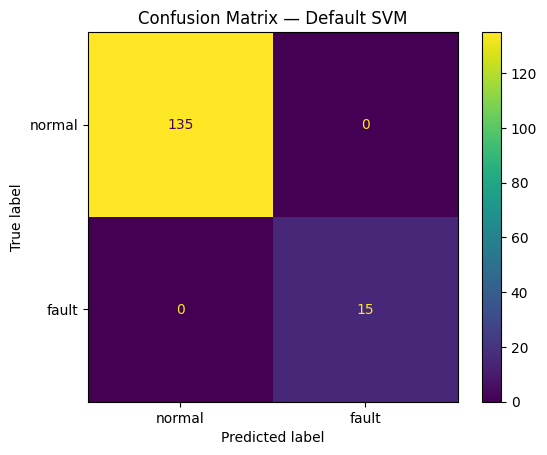

In [16]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["normal", "fault"])
plt.title("Confusion Matrix — Default SVM")
plt.show()

### Exercise 5
Identify TN, FP, FN, TP. Which error type is more critical in fault detection?

1. TN (True Negatives) = 135. Correctly predicted normal
2. FP (False Positives) = 0, No false alarms
3. FN (False Negatives) = 0, No missed faults
4. TP (True Positives) = 15, correctly predicted faults
5. False Negatives (FN) are most critical

## 8. ROC curve and AUC

The ROC curve shows how True Positive Rate and False Positive Rate change when the decision threshold changes.

- \(TPR = TP/(TP+FN)\)
- \(FPR = FP/(FP+TN)\)

AUC is the area under the ROC curve. AUC = 1 is perfect; AUC = 0.5 is random guessing.

ROC AUC: 1.0


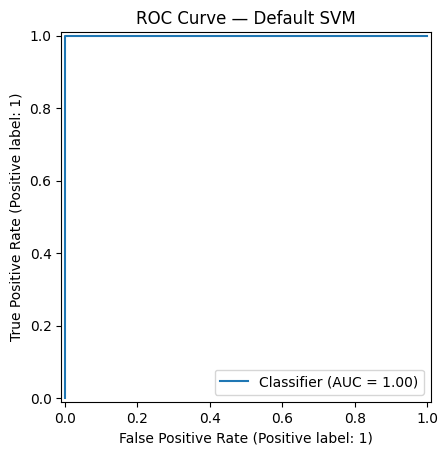

In [17]:
auc = roc_auc_score(y_test, y_score)
print("ROC AUC:", auc)
RocCurveDisplay.from_predictions(y_test, y_score)
plt.title("ROC Curve — Default SVM")
plt.show()

### Exercise 6
Explain ROC curve and AUC. Why are they useful before choosing a final threshold?

1. The ROC (Receiver Operating Characteristic) curve shows how a model performs across all possible classification thresholds.
2. AUC (Area Under the ROC Curve) measures the overall ability of the model to distinguish between classes.
3. Because they evaluate the model independently of any single threshold, shows all possible trade-offs, helps choose the right threshold, works well with imbalanced data.

## 9. Cross-validation

In [24]:
cv_scores = cross_val_score(svm_pipeline, X_train, y_train, cv=5, scoring="f1")
print("CV F1 scores:", cv_scores)
print("Mean:", cv_scores.mean())
print("Std:", cv_scores.std())

CV F1 scores: [1. 1. 1. 1. 1.]
Mean: 1.0
Std: 0.0


### Exercise 7
Why is cross-validation better than a single split? Why use F1 instead of accuracy here?

1. Cross-validation is better than a single split because it evaluates the model on multiple data partitions, providing a more reliable and stable performance estimate. F1-score is preferred over accuracy because the dataset is imbalanced, and F1 balances precision and recall, giving a better measure of fault detection performance.

## 10. Hyperparameter tuning with grid search

In [25]:
param_grid = {
    "svm__C": [0.1, 1, 10],
    "svm__gamma": [0.01, 0.1, "scale"],
}

grid = GridSearchCV(
    svm_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=1,
)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

Best parameters: {'svm__C': 1, 'svm__gamma': 0.1}
Best CV F1: 1.0


### Exercise 8
Explain why we tune `C` and `gamma`, why grid search uses only training data, and why cross-validation is used inside grid search.

1. We tune C and γ because they control the complexity and flexibility of the SVM model.
2. Grid search uses only training data to avoid data leakage and ensure a fair evaluation on unseen test data.
3. Cross-validation is used inside grid search to obtain a reliable and stable estimate of performance for each parameter combination.

## 11. Evaluate tuned model

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
ROC AUC: 1.0
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00       135
       fault       1.00      1.00      1.00        15

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



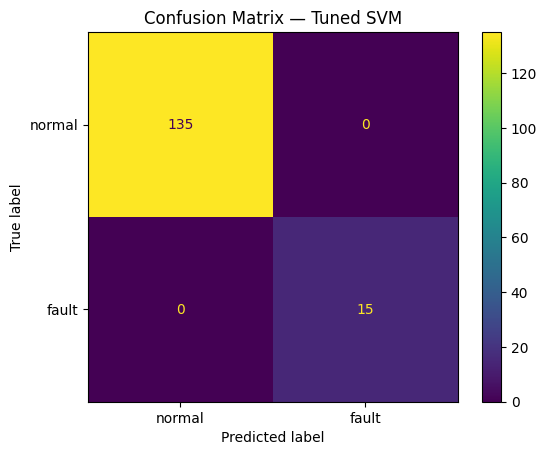

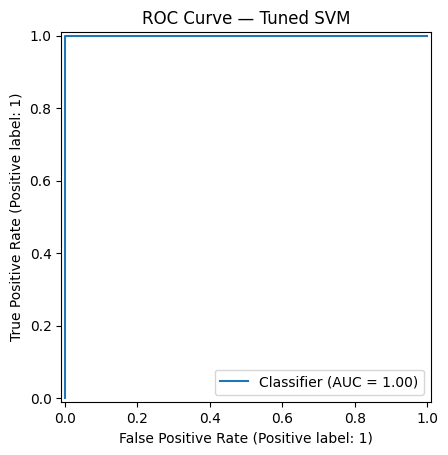

In [26]:
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)
y_score_best = best_model.decision_function(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1-score:", f1_score(y_test, y_pred_best))
print("ROC AUC:", roc_auc_score(y_test, y_score_best))
print(classification_report(y_test, y_pred_best, target_names=["normal", "fault"]))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, display_labels=["normal", "fault"])
plt.title("Confusion Matrix — Tuned SVM")
plt.show()
RocCurveDisplay.from_predictions(y_test, y_score_best)
plt.title("ROC Curve — Tuned SVM")
plt.show()

### Exercise 9
Compare default and tuned SVM. Which metrics improved? What trade-off do you observe?

1. All evaluation metrics improved to perfect values. The main trade-off is increased model complexity, which may lead to overfitting. Although performance is excellent on the test set, the model should be validated further to ensure it generalizes well to new data.

## 12. Robustness test: sensor noise

In [28]:
def evaluate_under_noise(model, X_test, y_test, noise_std_values):
    results = []
    rng = np.random.default_rng(RANDOM_STATE)
    for noise_std in noise_std_values:
        noise = rng.normal(0, noise_std, X_test.shape)
        X_noisy = X_test.copy() + noise
        y_pred_noisy = model.predict(X_noisy)
        y_score_noisy = model.decision_function(X_noisy)
        results.append({
            "noise_std": noise_std,
            "accuracy": accuracy_score(y_test, y_pred_noisy),
            "precision": precision_score(y_test, y_pred_noisy, zero_division=0),
            "recall": recall_score(y_test, y_pred_noisy, zero_division=0),
            "f1": f1_score(y_test, y_pred_noisy, zero_division=0),
            "auc": roc_auc_score(y_test, y_score_noisy),
        })
    return pd.DataFrame(results)

noise_results = evaluate_under_noise(best_model, X_test, y_test, [0, 0.5, 1.0, 2.0, 3.0])
noise_results

,noise_std,accuracy,precision,recall,f1,auc
0,0.0,1.000000,1.000000,1.000000,1.000000,1.000000
1,0.5,0.993333,1.000000,0.933333,0.965517,1.000000
2,1.0,0.960000,0.714286,1.000000,0.833333,0.998519
3,2.0,0.606667,0.202703,1.000000,0.337079,0.915062
4,3.0,0.380000,0.117647,0.800000,0.205128,0.719012


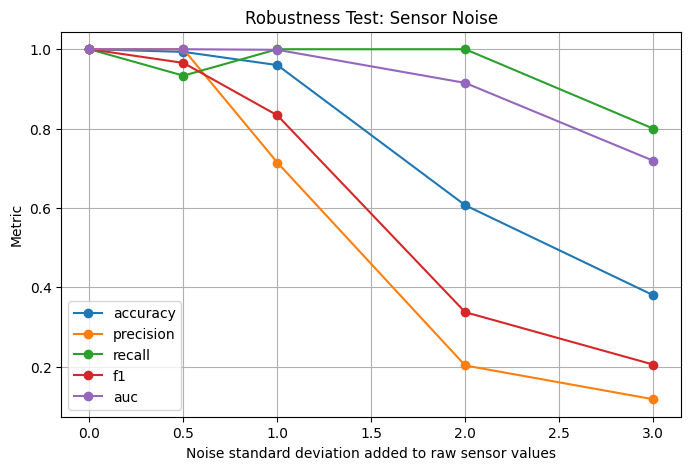

In [29]:
plt.figure(figsize=(8, 5))
for metric in ["accuracy", "precision", "recall", "f1", "auc"]:
    plt.plot(noise_results["noise_std"], noise_results[metric], marker="o", label=metric)
plt.xlabel("Noise standard deviation added to raw sensor values")
plt.ylabel("Metric")
plt.title("Robustness Test: Sensor Noise")
plt.legend()
plt.grid(True)
plt.show()

### Exercise 10
Interpret robustness results. Which metric drops first? Is recall still acceptable? What further robustness tests would be needed in a real project?

## 13. Final reflection
Answer:

1. Why is preprocessing essential for SVMs?
2. Why is accuracy insufficient for safety-critical systems?
3. Why is recall important in fault detection?
4. What does AUC tell us that accuracy does not?
5. Why is hyperparameter tuning part of engineering a reliable ML system?
6. Why is robustness testing necessary before deployment?

1. Because without preprocessing, the decision boundary can be distorted and performance degrades.
2. In safety-critical systems, the type of mistake matters more than the total number of correct predictions.
3. Recall measures how many real faults are detected.High recall means few missed fault and safer system operation.
4. Accuracy only evaluates performance at one fixed threshold, while AUC evaluates all possible thresholds.
5. Hyperparameter tuning improves generalization,prevents underfitting and overfitting,leads to more robust and reliable performance.
6. A model may perform well on test data but fail in real-world conditions. Robustness testing  is critical for safety, reliability and real-world deployment confidence.